# Chain

## Messages

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models

In [ ]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="qwen3:8b")
result = llm.invoke(messages)
type(result)

result.response_metadata

{'model': 'qwen3:8b',
 'created_at': '2026-04-25T06:57:59.775507Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 78181966667,
 'load_duration': 4036233917,
 'prompt_eval_count': 66,
 'prompt_eval_duration': 524687625,
 'eval_count': 1571,
 'eval_duration': 73224731273,
 'logprobs': None,
 'model_name': 'qwen3:8b',
 'model_provider': 'ollama'}

In [4]:
result

AIMessage(content="The United States has several prime locations for observing Orcas (also known as killer whales), particularly in the Pacific Northwest and Alaska. Here are the **best places** to see them, along with tips for maximizing your chances:\n\n---\n\n### **1. San Juan Islands, Washington**  \n- **Why it's great**: The San Juan Islands (part of the San Juan Island National Historical Park) are a top destination for Orca sightings. Orcas frequent the waters year-round, especially during the summer months (June–September).  \n- **How to see them**:  \n  - Take a **whale-watching tour** from Friday Harbor or Coupeville (reachable by ferry from Seattle).  \n  - Use **real-time tracking apps** like [Orca Watch](https://www.orcawatch.org/) or the [National Oceanic and Atmospheric Administration (NOAA)](https://www.noaa.gov) to locate pods.  \n- **Best time**: Summer and fall (September–October) when Orcas are more active in the area.\n\n---\n\n### **2. Puget Sound, Washington**  \

## Tools

In [5]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])
tool_call

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-04-25T06:58:06.061098Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6227893750, 'load_duration': 88014125, 'prompt_eval_count': 153, 'prompt_eval_duration': 645812583, 'eval_count': 126, 'eval_duration': 5467823670, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019dc36e-5017-7763-ba42-9d3fd822b40c-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '73daf865-47a2-4951-932c-55de55dbb4cf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 153, 'output_tokens': 126, 'total_tokens': 279})

In [6]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': '73daf865-47a2-4951-932c-55de55dbb4cf',
  'type': 'tool_call'}]

## Using messages as State

In [7]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

### Reducers

In [13]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


from langgraph.graph import MessagesState

# This is a shortcut readily available from the langraph, which internally does the same thing as the above code snippet, but is more concise and easier to use.
class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass


# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='ec4ed104-cf10-45c8-b675-a729a63a3029', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='e28ea76f-b27e-47d4-b2d0-755abaf8e39f'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='4ba87a0a-4156-441f-acc9-a6d603301719', tool_calls=[], invalid_tool_calls=[])]

## Our Graph

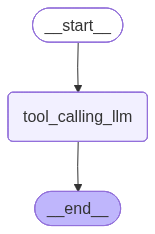

In [14]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today? If you have any questions or need help with calculations, feel free to ask! 😊


In [11]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (b4094ba7-502c-4465-8e71-e4f7f832531c)
 Call ID: b4094ba7-502c-4465-8e71-e4f7f832531c
  Args:
    a: 2
    b: 3
